# Deutsch–Jozsa Algorithm

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
import numpy as np
from IPython.display import display
from typing import Dict

In [2]:
def run_and_plot_counts(circ, backend, shots=1024, title=None) -> Dict[str, int]:
    """Run a circuit and return counts in |q0 ... qn> order."""

    job = backend.run(circ, shots=shots)
    result = job.result()
    counts = result.get_counts(0)

    counts_left_order = {
        bitstring[::-1]: count
        for bitstring, count in counts.items()
    }

    display(plot_histogram(counts_left_order, title=title))
    return counts_left_order


In [3]:
def get_statevector(circ):
    """Return Statevector reordered to |q0 ... qn> basis."""

    sv = Statevector.from_instruction(circ)
    n = int(np.log2(len(sv)))

    reordered = np.zeros_like(sv.data, dtype=complex)

    for i, amp in enumerate(sv.data):
        b = format(i, f"0{n}b")
        b_rev = b[::-1]
        j = int(b_rev, 2)
        reordered[j] = amp

    return Statevector(reordered)

In [7]:
def deutsch_jozsa_oracle(n, balanced=True):
    qc = QuantumCircuit(n+1)
    if balanced:
        qc.cx(0, n)  # Qiskit bit order reversed logically
    else:
        qc.x(n)
        pass
    return qc

In [9]:
def deutsch_jozsa(n, balanced=True):
    qc = QuantumCircuit(n+1, n)
    qc.x(n)
    qc.h(range(n+1))
    qc.barrier()

    qc.compose(deutsch_jozsa_oracle(n, balanced), inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.barrier()
    sv = get_statevector(qc)
    display(sv.draw('latex', prefix="|psi⟩ = "))

    qc.measure(range(n), range(n))
    return qc

<IPython.core.display.Latex object>

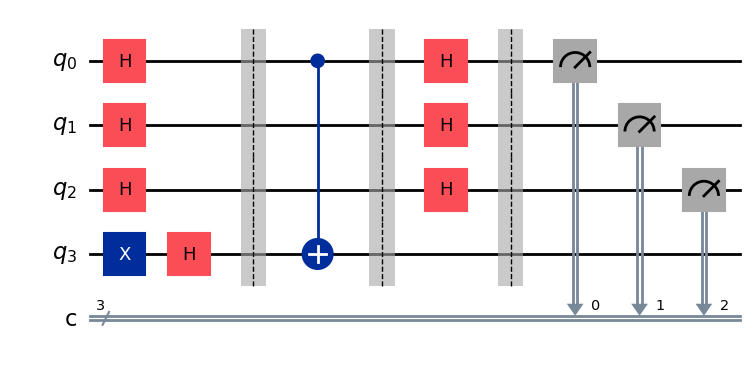

In [12]:
qc_dj_balanced = deutsch_jozsa(3, balanced=True)
qc_dj_balanced.draw('mpl')

<IPython.core.display.Latex object>

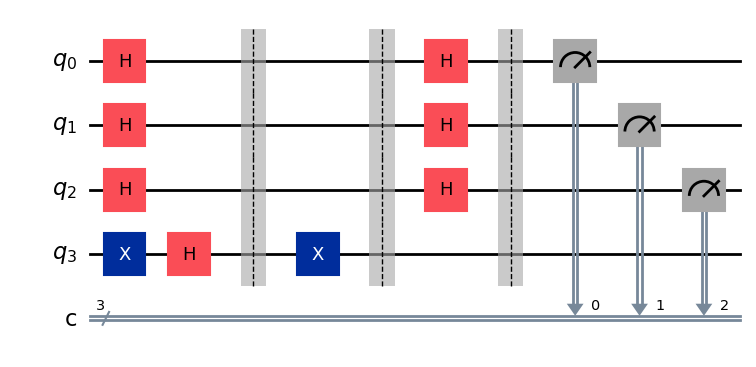

In [13]:
qc_dj_const = deutsch_jozsa(3, balanced=False)
qc_dj_const.draw('mpl')

In [14]:
ideal_sim = AerSimulator()
noisy_sim = FakeSherbrooke()

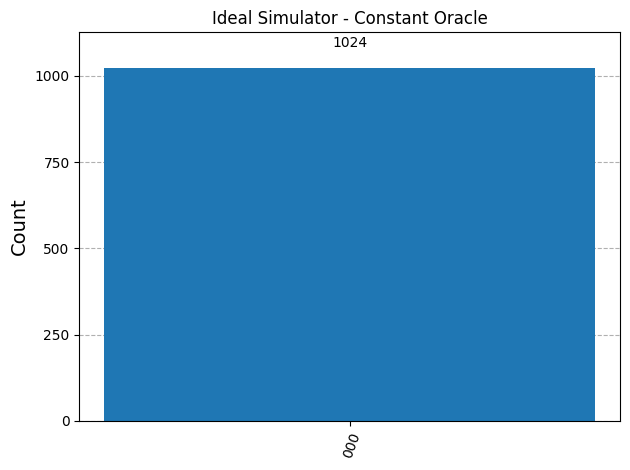

{'000': 1024}

In [15]:
run_and_plot_counts(
    qc_dj_const, ideal_sim, title="Ideal Simulator - Constant Oracle"
)

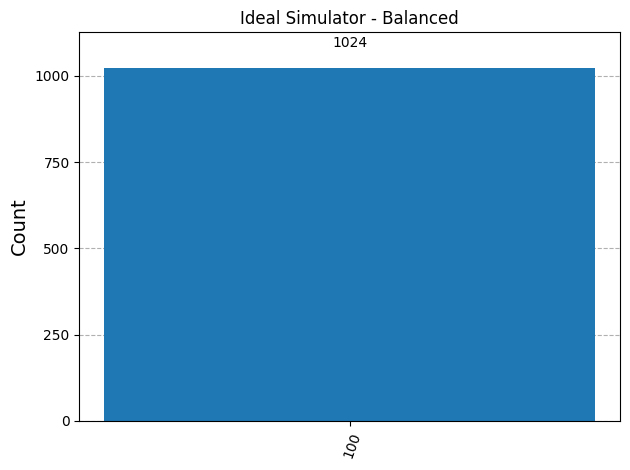

{'100': 1024}

In [16]:
run_and_plot_counts(
    qc_dj_balanced, ideal_sim, title="Ideal Simulator - Balanced"
)

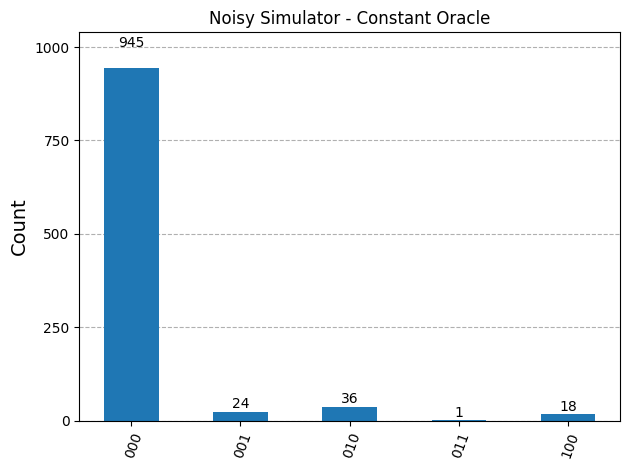

{'011': 1, '100': 18, '001': 24, '010': 36, '000': 945}

In [17]:
run_and_plot_counts(
    qc_dj_const, noisy_sim, title="Noisy Simulator - Constant Oracle"
)

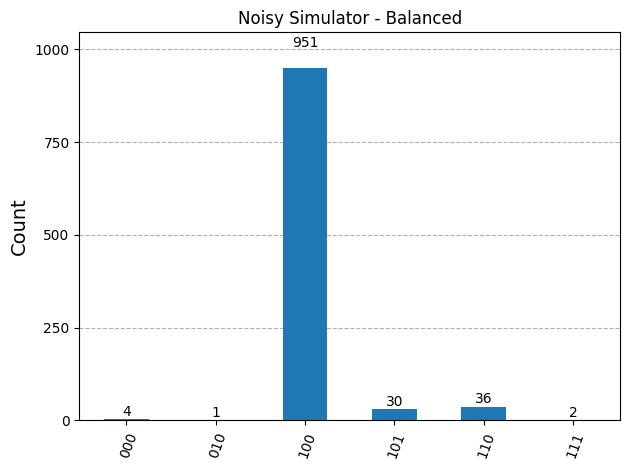

{'010': 1, '000': 4, '111': 2, '110': 36, '101': 30, '100': 951}

In [18]:
run_and_plot_counts(
    qc_dj_balanced, noisy_sim, title="Noisy Simulator - Balanced"
)